# Computing the Nullspace of the Sheaf Laplacian

## Introduction

This example demonstrates how to compute and visualize the nullspace of the Laplacian operator
for a circular cellular sheaf. We construct a system of 6 agents, each with 3-dimensional stalks,
arranged in a cycle topology. The nullspace of the Laplacian contains the global sections---the
solutions that are preserved by the sheaf Laplacian operator. Understanding the structure of this
nullspace is fundamental to understanding the harmonic analysis and signal processing on cellular sheaves.

In [1]:
using CellularSheaves
using CliqueTrees.Multifrontal
using LinearAlgebra
using Plots
using SparseArrays

## Building the Sheaf

We start by creating a Euclidean sheaf with 6 vertices (agents), each equipped with a 3-dimensional
vector space as its stalk. The stalks represent local data or state at each agent.

In [2]:
n = 6
stalk_dim = 3

F = EuclideanSheaf{Float64}(Int[])

for i in 1:n
    add_vertex_stalk!(F, stalk_dim)
end

Next, we add edges connecting the agents in a cycle. Each edge is equipped with the identity
restriction map, meaning that sections on adjacent agents must have the same value where they overlap.

In [3]:
for i in 1:n
    v1 = i
    v2 = (i % n) + 1
    rm = Matrix{Float64}(I, stalk_dim, stalk_dim)
    add_sheaf_edge!(F, v1, v2, rm, rm)
end

## Computing the Laplacian

The Laplacian of a sheaf is derived from the coboundary map. We first compute the coboundary operator,
then form the Laplacian as the Gram matrix X = C^T * C. The Laplacian is a symmetric positive
semidefinite matrix whose nullspace corresponds to global sections.

In [4]:
C = sparse(coboundary_map(F))
X = C' * C

18×18 SparseArrays.SparseMatrixCSC{Float64, Int64} with 162 stored entries:
⎡⣿⣿⣿⣀⡀⠀⠀⠸⠿⎤
⎢⠛⢻⣿⣿⣧⣤⠀⠀⠀⎥
⎢⠀⠈⠉⣿⣿⣿⣶⡆⠀⎥
⎢⣀⡀⠀⠀⠸⠿⣿⣿⣿⎥
⎣⠛⠃⠀⠀⠀⠀⠛⠛⠛⎦

## Computing the Nullspace via LDLt Factorization

We use a Chordal LDLt factorization to efficiently compute the nullspace. This factorization
decomposes the Laplacian as
$$
X = P^T * L * D * L^T * P
$$
where L is lower triangular, D is diagonal,
and P is a permutation. The nullspace corresponds to the zero entries on the diagonal of D.

In [5]:
M = ldlt!(ChordalLDLt(X), RowMaximum())

L = M.L # lower triangular factor
D = M.D # diagonal factor
P = M.P # permutation

18×18 FPermutation{Int64}:
 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  1  0  0
 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  1  0
 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  1
 0  0  0  0  0  0  0  0  0  1  0  0  0  0  0  0  0  0
 0  0  0  0  0  0  0  0  0  0  1  0  0  0  0  0  0  0
 0  0  0  0  0  0  0  0  0  0  0  1  0  0  0  0  0  0
 0  0  0  0  0  0  0  0  0  0  0  0  1  0  0  0  0  0
 0  0  0  0  0  0  0  0  0  0  0  0  0  1  0  0  0  0
 0  0  0  0  0  0  0  0  0  0  0  0  0  0  1  0  0  0
 0  0  0  1  0  0  0  0  0  0  0  0  0  0  0  0  0  0
 0  0  0  0  1  0  0  0  0  0  0  0  0  0  0  0  0  0
 0  0  0  0  0  1  0  0  0  0  0  0  0  0  0  0  0  0
 0  1  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
 1  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
 0  0  0  0  0  0  0  0  1  0  0  0  0  0  0  0  0  0
 0  0  0  0  0  0  1  0  0  0  0  0  0  0  0  0  0  0
 0  0  0  0  0  0  0  1  0  0  0  0  0  0  0  0  0  0
 0  0  1  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0

Identify the indices where D has (numerically) zero diagonal entries. These correspond to the
nullspace directions. We construct a basis for the nullspace by back-solving the factorization.

In [6]:
max_abs_diag = maximum(i -> abs(D[i, i]), 1:size(D, 1); init=0.0)
tol = eps(Float64) * max(1.0, max_abs_diag)
ind = findall(i -> abs(D[i, i]) <= tol, 1:size(D, 1))
U = zeros(size(D, 1), length(ind))

for j in eachindex(ind)
    U[ind[j], j] = 1
end

V = P \ (L' \ U)

18×3 Matrix{Float64}:
 1.0  0.0  0.0
 0.0  1.0  0.0
 0.0  0.0  1.0
 1.0  0.0  0.0
 0.0  1.0  0.0
 0.0  0.0  1.0
 1.0  0.0  0.0
 0.0  1.0  0.0
 0.0  0.0  1.0
 1.0  0.0  0.0
 0.0  1.0  0.0
 0.0  0.0  1.0
 1.0  0.0  0.0
 0.0  1.0  0.0
 0.0  0.0  1.0
 1.0  0.0  0.0
 0.0  1.0  0.0
 0.0  0.0  1.0

## Visualizing the Nullspace Basis

Each column of V is a basis vector in the nullspace. We visualize all basis vectors simultaneously
using three orthogonal projections (x vs y, y vs z, x vs z) arranged in a grid. Each basis vector
is displayed in a distinct color, with agent indices shown as annotated markers.

In [7]:
num_basis_vectors = size(V, 2)
colors = palette(:tab10, num_basis_vectors)

Extract coordinate components for each agent
Coordinates are strided in V with period stalk_dim

In [8]:
x_coords = V[1:stalk_dim:end, :]  # first row in each stalk_dim-sized block
y_coords = V[2:stalk_dim:end, :]  # second row in each stalk_dim-sized block
z_coords = V[3:stalk_dim:end, :]  # third row in each stalk_dim-sized block

6×3 Matrix{Float64}:
 0.0  0.0  1.0
 0.0  0.0  1.0
 0.0  0.0  1.0
 0.0  0.0  1.0
 0.0  0.0  1.0
 0.0  0.0  1.0

Create three projection subplots

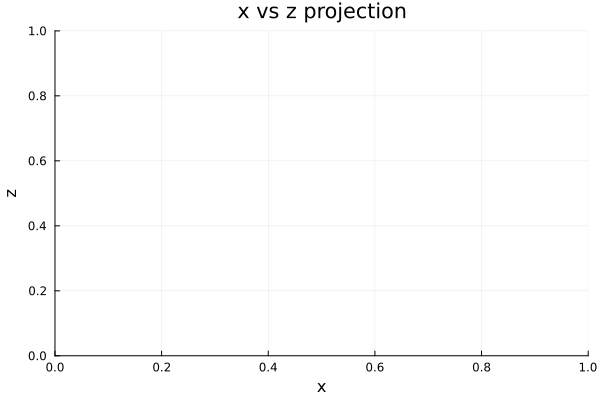

In [9]:
p1 = scatter(legend=false, xlabel="x", ylabel="y", title="x vs y projection",
    markersize=8, markerstrokewidth=1.5)
p2 = scatter(legend=false, xlabel="y", ylabel="z", title="y vs z projection",
    markersize=8, markerstrokewidth=1.5)
p3 = scatter(legend=false, xlabel="x", ylabel="z", title="x vs z projection",
    markersize=8, markerstrokewidth=1.5)

Plot each basis vector with color coding

In [10]:
for b in 1:num_basis_vectors
    x_vals = x_coords[:, b]
    y_vals = y_coords[:, b]
    z_vals = z_coords[:, b]

    scatter!(p1, x_vals, y_vals, color=colors[b], label="basis $b",
        markersize=6, markerstrokewidth=0.5)

    scatter!(p2, y_vals, z_vals, color=colors[b], label="basis $b",
        markersize=6, markerstrokewidth=0.5)

    scatter!(p3, x_vals, z_vals, color=colors[b], label="basis $b",
        markersize=6, markerstrokewidth=0.5)
end

Arrange the three projections in a 2×2 grid layout, leaving the bottom-right cell empty

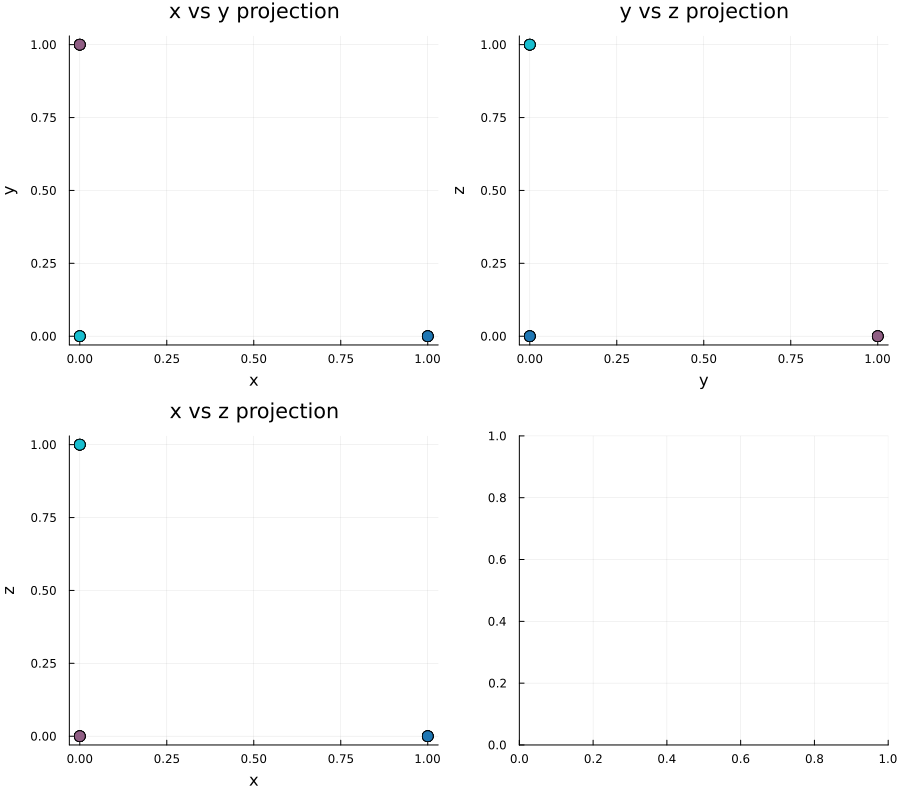

In [11]:
plot_grid = @layout [a b; c d]
plot(p1, p2, p3, plot(), layout=plot_grid, size=(900, 800))